In [7]:
import sys
print(sys.executable)

c:\Users\navee\Documents\langgraph\myenv\Scripts\python.exe


In [11]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [17]:
# Define State
class BMIState(TypedDict):
    weight: float
    height: float
    bmi: float
    classification: str



In [18]:
# Define function to calculate BMI
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight'] 
    height = state['height']
    bmi = weight / (height ** 2)
    
    state['bmi']=round(bmi, 2)
    return state

def classify_bmi(state: BMIState) -> BMIState:
    bmi = state['bmi']
    if bmi < 18.5:
        state['classification'] = 'Underweight'
    elif 18.5 <= bmi < 25:
        state['classification'] = 'Normal weight'
    elif 25 <= bmi < 30:
        state['classification'] = 'Overweight'
    else:
        state['classification'] = 'Obese'
    return state

In [19]:
# define graph
graph= StateGraph(BMIState)

# Add node
graph.add_node("calculate_bmi",calculate_bmi)
graph.add_node("categories",classify_bmi)

# Add edges
graph.add_edge(START,"calculate_bmi")
graph.add_edge("calculate_bmi","categories")
graph.add_edge("categories",END)


# Compile Graph
workflow = graph.compile()

In [20]:
# Execute Graph
initial_state = {'weight': 70, 'height': 1.75}
final_state = workflow.invoke(initial_state)

print(final_state)

{'weight': 70, 'height': 1.75, 'bmi': 22.86, 'classification': 'Normal weight'}


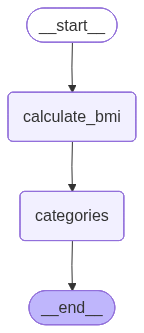

In [21]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())
